# Chương 5. HỌC SÂU

## Đọc và hiển thị hình ảnh

Image shape: (1000, 1500, 3)


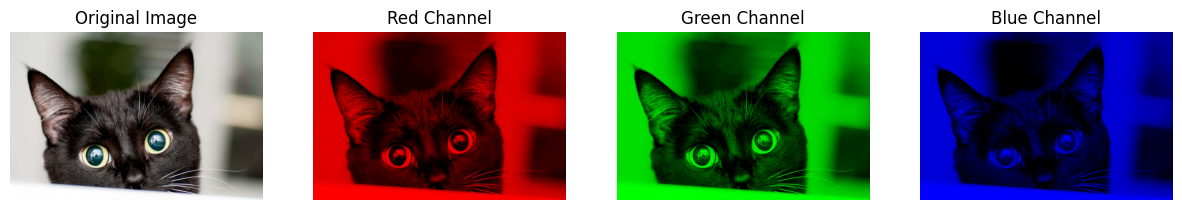

In [1]:
import matplotlib.pyplot as plt
import numpy as np

# Đọc ảnh màu
im = plt.imread('./picture/cute_black_cat.jpg')

# Kiểm tra kích thước ảnh
print("Image shape:", im.shape)

# Xuất các kênh màu
red_channel = im.copy()
red_channel[:, :, 1] = 0  # Chuyển kênh xanh lá về 0
red_channel[:, :, 2] = 0  # Chuyển kênh xanh dương về 0

green_channel = im.copy()
green_channel[:, :, 0] = 0  # Chuyển kênh xanh đỏ về 0
green_channel[:, :, 2] = 0  # Chuyển kênh xanh dương về 0

blue_channel = im.copy()
blue_channel[:, :, 0] = 0  # Chuyển kênh xanh đỏ về 0
blue_channel[:, :, 1] = 0  # Chuyển kênh xanh lá về 0

# Hiển thị ảnh gốc và ảnh sau khi đã xử lý
fig, ax = plt.subplots(1, 4, figsize=(15, 5))
ax[0].imshow(im)
ax[0].set_title("Original Image")
ax[0].axis("off")

ax[1].imshow(red_channel)
ax[1].set_title("Red Channel")
ax[1].axis("off")

ax[2].imshow(green_channel)
ax[2].set_title("Green Channel")
ax[2].axis("off")

ax[3].imshow(blue_channel)
ax[3].set_title("Blue Channel")
ax[3].axis("off")

plt.show()


## Xoay và làm méo ảnh

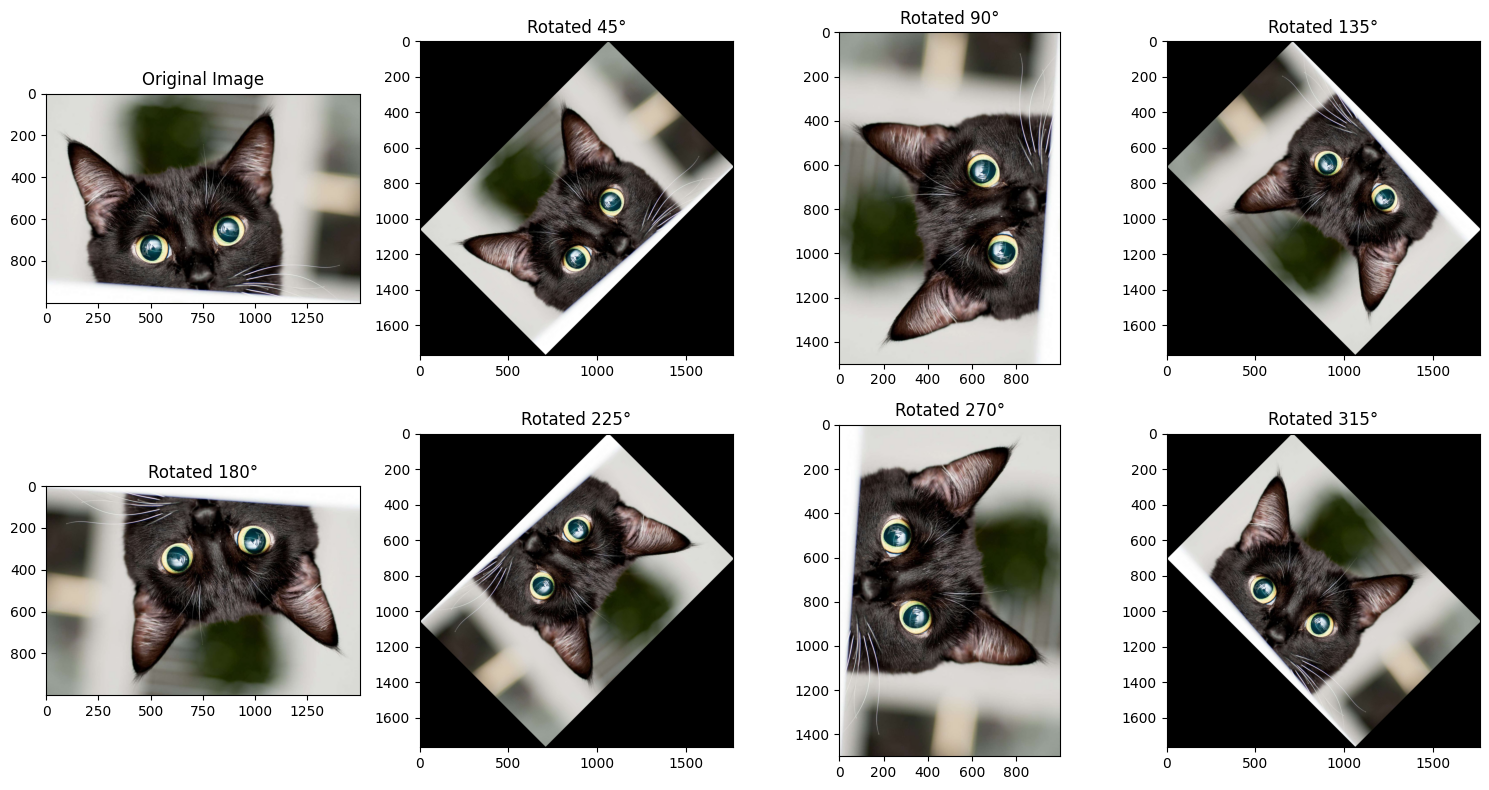

In [2]:
from scipy.ndimage import rotate
# Cài đặt các góc xoay
angles = [45, 90, 135, 180, 225, 270, 315]
rotated_images = [rotate(im, angle) for angle in angles]

# Hiển thị các ảnh sau khi đã thực hiện các phép xoay với góc xoay tương ứng
fig, ax = plt.subplots(2, 4, figsize=(15, 8))  

ax[0, 0].imshow(im)
ax[0, 0].set_title("Original Image")
ax[0, 0].axis("on")

for i, (rot_img, angle) in enumerate(zip(rotated_images, angles), start=1):
    ax[i // 4, i % 4].imshow(rot_img)
    ax[i // 4, i % 4].set_title(f"Rotated {angle}°")
    ax[i // 4, i % 4].axis("on")

plt.tight_layout()
plt.show()


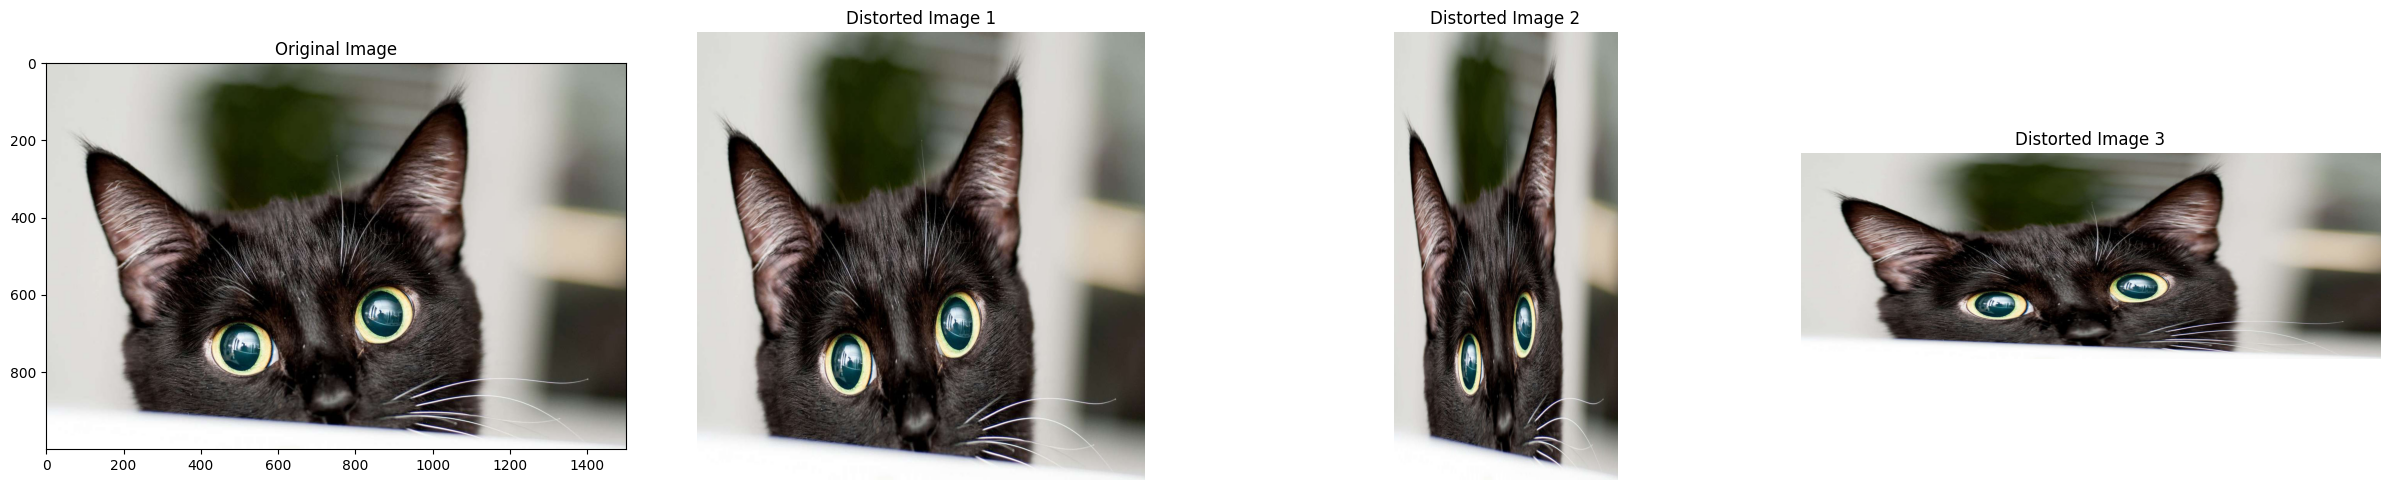

In [ ]:
from scipy.ndimage import rotate, zoom


# Làm dẹp ảnh thành 1D vectơ
flattened_image = im.reshape(-1)  # vectơ phẳng 1D

# Xoay ảnh
angles = [45, 90, 135, 180, 225, 270, 315]
rotated_images = [rotate(im, angle) for angle in angles]
flattened_rotated_images = [rot_img.reshape(-1) for rot_img in rotated_images]  

# Làm méo ảnh
zoom_factors = [(1.2, 0.8, 1), (1.5, 0.5, 1), (0.8, 1.5, 1)] # tỷ lệ méo ảnh (x, y, z)
distorted_images = [zoom(im, zoom_factor) for zoom_factor in zoom_factors]

# Làm biến dạng ảnh
flattened_distorted_images = [dist_img.reshape(-1) for dist_img in distorted_images]

# Trực quan
fig, ax = plt.subplots(1, 4, figsize=(24, 5))

# Ảnh gốc
ax[0].imshow(im)
ax[0].set_title("Original Image")
ax[0].axis("on")

# Ảnh đã xử lý
for i, dist_img in enumerate(distorted_images):
    ax[i+1].imshow(dist_img)
    ax[i+1].set_title(f"Distorted Image {i+1}")
    ax[i+1].axis("off")

plt.tight_layout()
plt.show()

## Thêm hiệu ứng cho ảnh

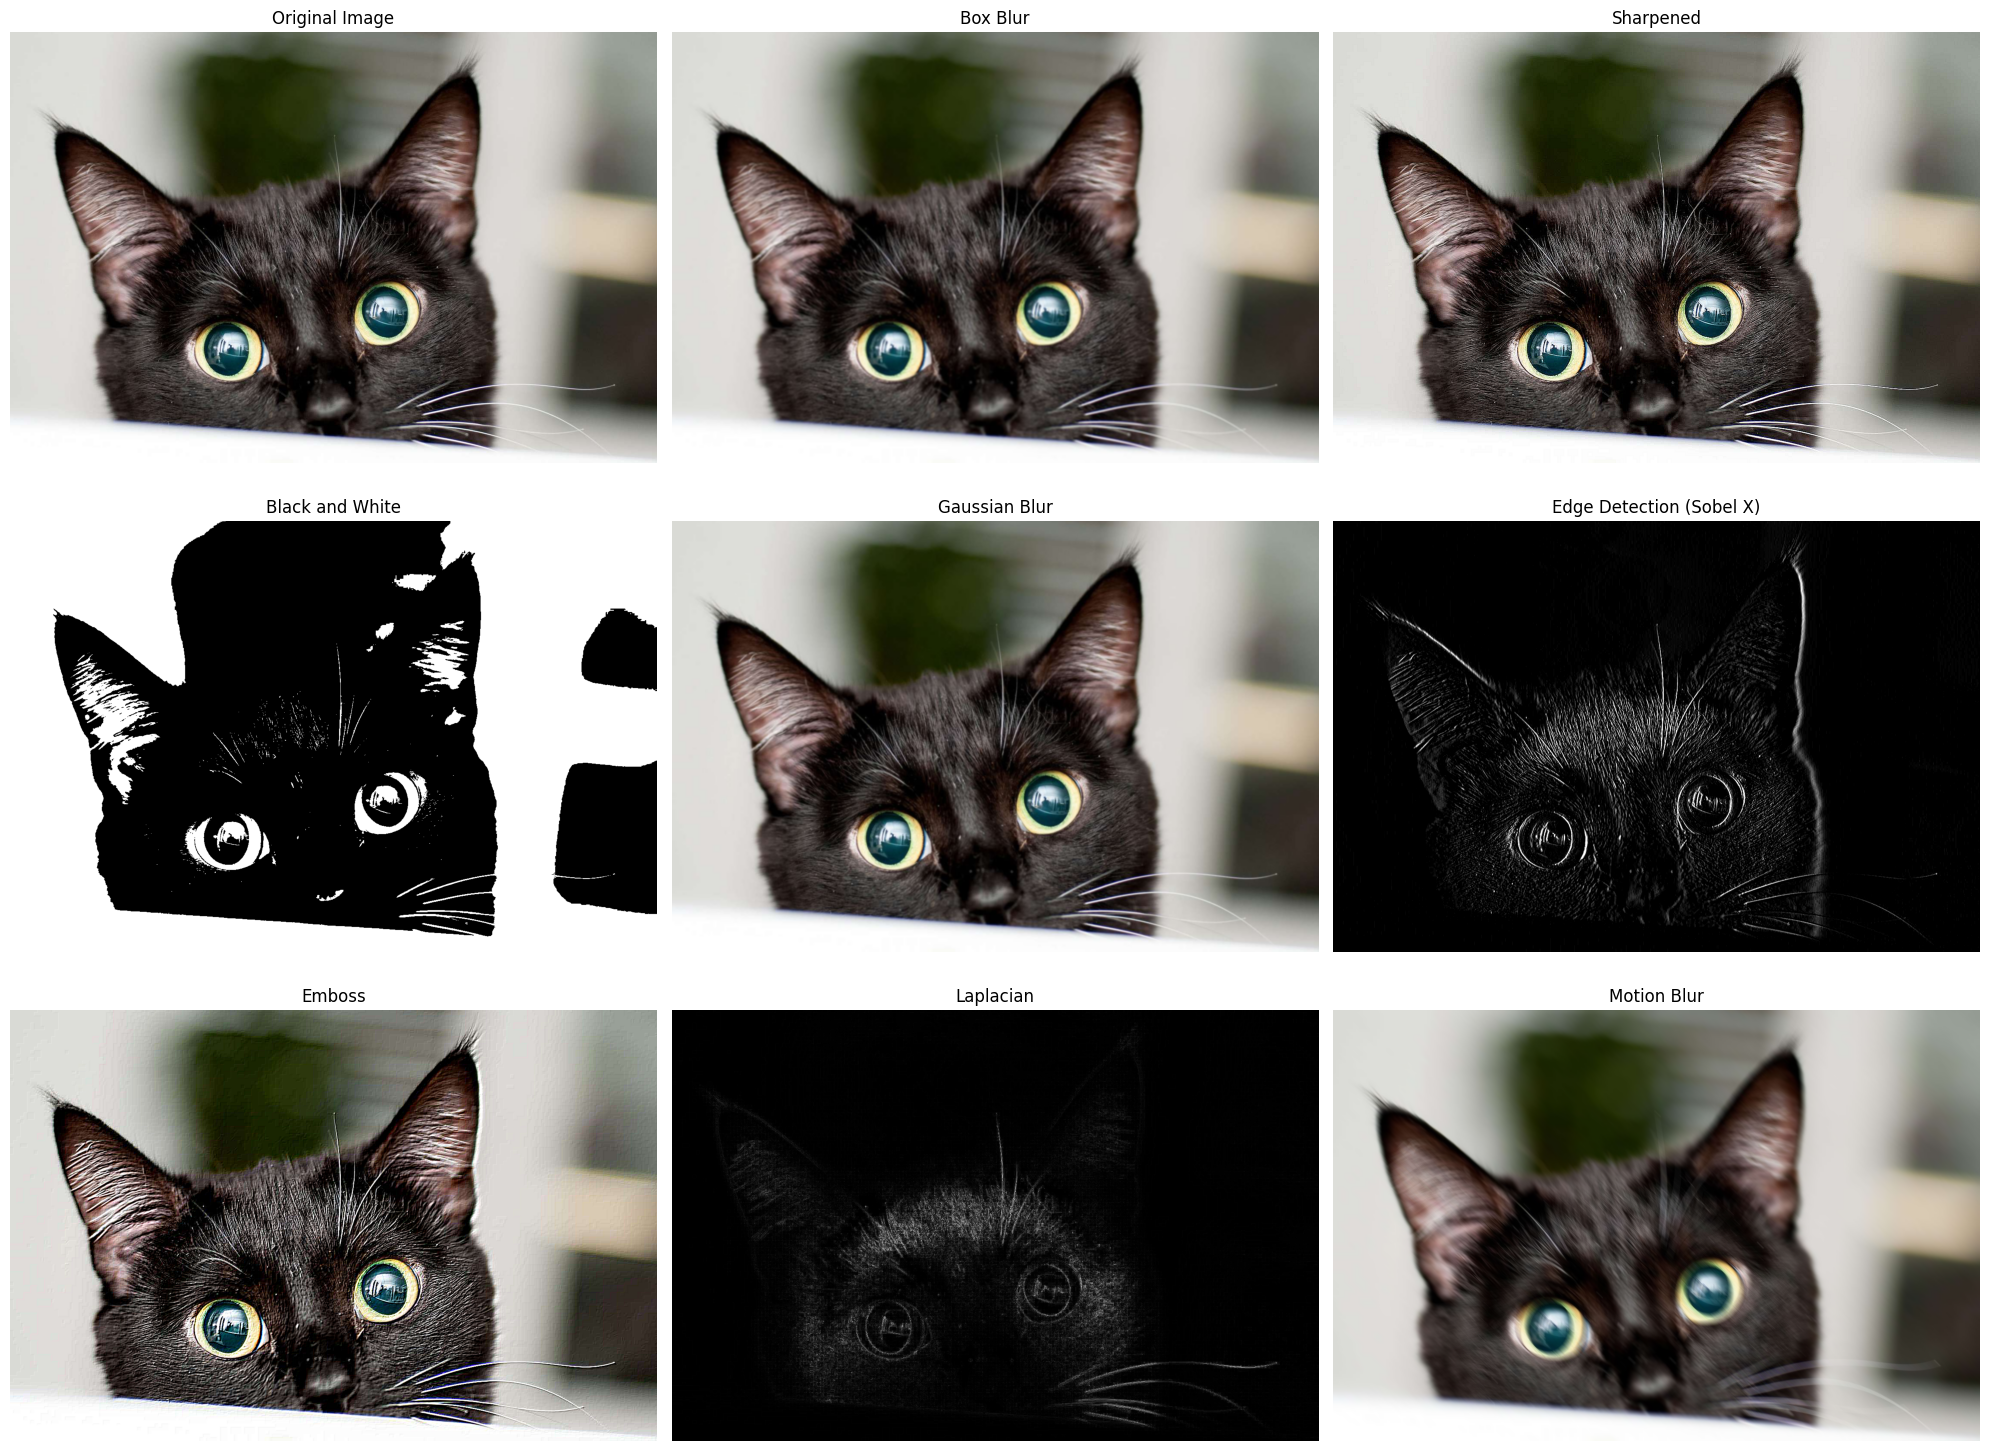

In [ ]:
import cv2

# 1. Original Image (Ảnh gốc)
original_image = im

# 2. Box Blur (Kernel trung bình)
box_blur_kernel = np.ones((5, 5), np.float32) / 25
box_blur_image = cv2.filter2D(im, -1, box_blur_kernel)

# 3. Sharp (Sắc nét)
sharp_kernel = np.array([[0, -1, 0],
                         [-1, 5, -1],
                         [0, -1, 0]])
sharp_image = cv2.filter2D(im, -1, sharp_kernel)

# 4. Black and White (Đen trắng)
gray_image = cv2.cvtColor(im, cv2.COLOR_RGB2GRAY)
_, black_white_image = cv2.threshold(gray_image, 127, 255, cv2.THRESH_BINARY)

# 5. Gaussian Blur (Làm mờ Gaussian)
gaussian_blur_image = cv2.GaussianBlur(im, (5, 5), 0)

# 6. Edge Detection (Sobel X)
sobel_x_kernel = np.array([[-1, 0, 1],
                           [-2, 0, 2],
                           [-1, 0, 1]])
edge_detection_image = cv2.filter2D(gray_image, -1, sobel_x_kernel)

# 7. Emboss (Chạm nổi)
emboss_kernel = np.array([[-2, -1, 0],
                          [-1,  1, 1],
                          [ 0,  1, 2]])
emboss_image = cv2.filter2D(im, -1, emboss_kernel)

# 8. Laplacian (Phát hiện cạnh toàn cục)
laplacian_image = cv2.Laplacian(gray_image, cv2.CV_64F)
laplacian_image = np.uint8(np.absolute(laplacian_image))  

# 9. Motion Blur (Làm mờ chuyển động)
motion_blur_kernel = np.zeros((15, 15))
np.fill_diagonal(motion_blur_kernel, 1/15)  
motion_blur_image = cv2.filter2D(im, -1, motion_blur_kernel)

# Hiển thị kết quả
fig, ax = plt.subplots(3, 3, figsize=(20, 15))

filters = [
    ("Original Image", original_image),
    ("Box Blur", box_blur_image),
    ("Sharpened", sharp_image),
    ("Black and White", black_white_image),
    ("Gaussian Blur", gaussian_blur_image),
    ("Edge Detection (Sobel X)", edge_detection_image),
    ("Emboss", emboss_image),
    ("Laplacian", laplacian_image),
    ("Motion Blur", motion_blur_image)
]

for i, (title, image) in enumerate(filters):
    row, col = divmod(i, 3)
    if len(image.shape) == 2:  # Grayscale images
        ax[row, col].imshow(image, cmap='gray')
    else:  # RGB images
        ax[row, col].imshow(image)
    ax[row, col].set_title(title)
    ax[row, col].axis("off")

plt.tight_layout()
plt.show()


## Thêm lề cho ảnh

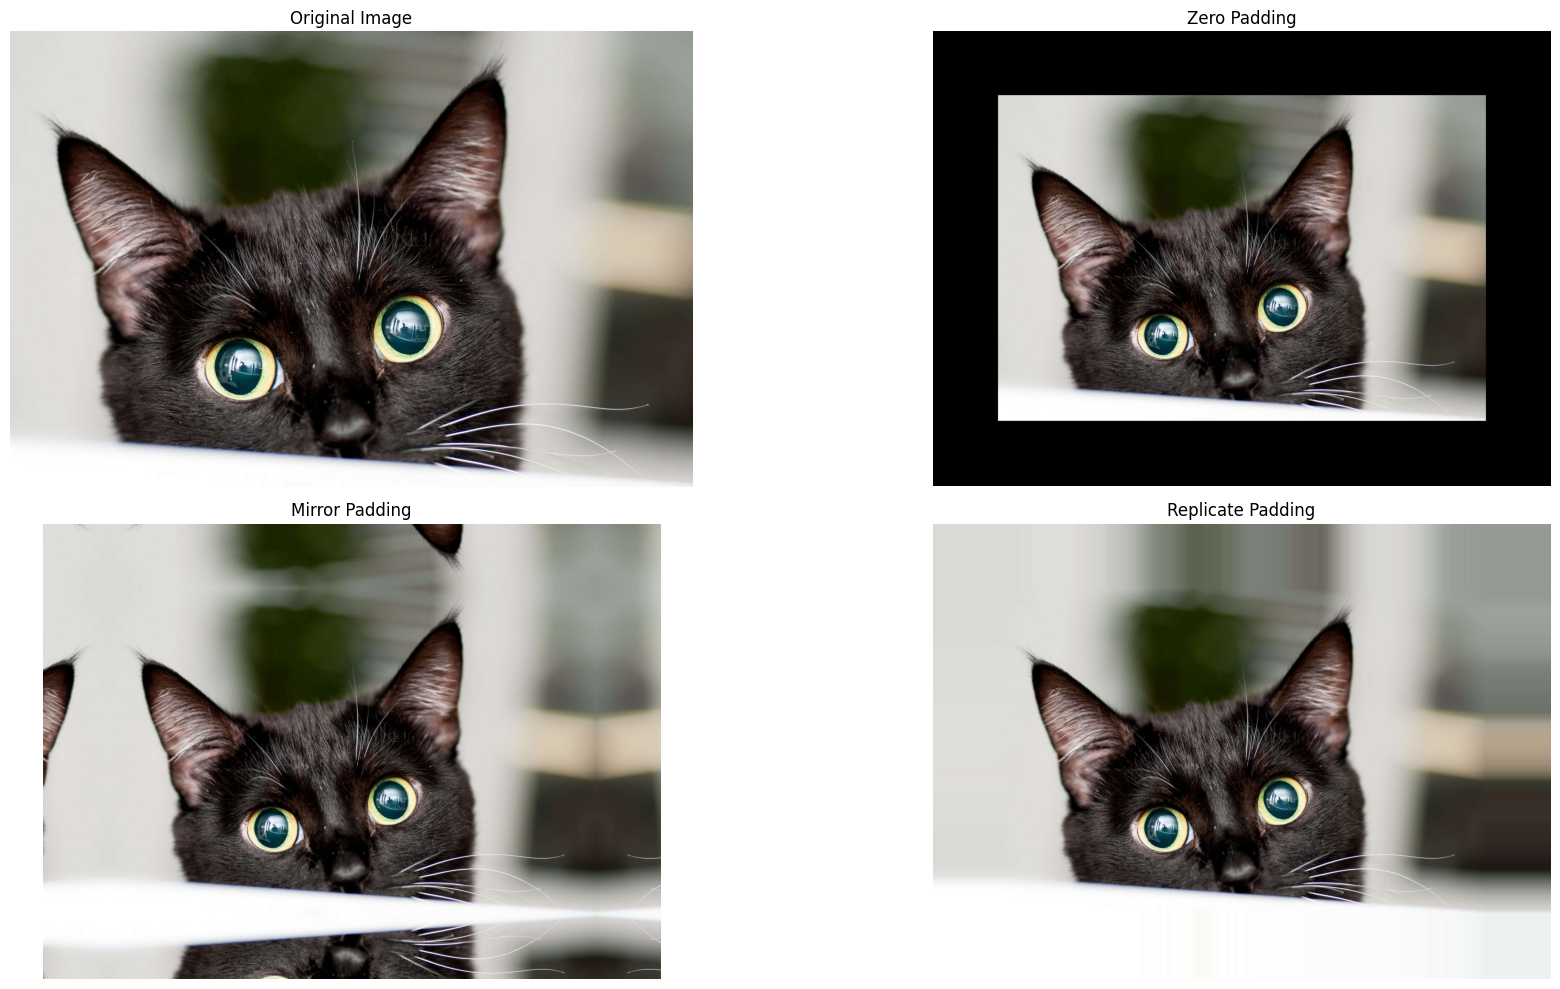

In [9]:
# Padding size
pad = 200

# 1. Zero Padding
zero_padded = cv2.copyMakeBorder(im, pad, pad, pad, pad, cv2.BORDER_CONSTANT, value=[0, 0, 0])

# 2. Mirror Padding (Reflect)
mirror_padded = cv2.copyMakeBorder(im, pad, pad, pad, pad, cv2.BORDER_REFLECT)

# 3. Replicate Padding (Repeat edge pixels)
replicate_padded = cv2.copyMakeBorder(im, pad, pad, pad, pad, cv2.BORDER_REPLICATE)

# Hiển thị ảnh gốc và 3 loại padding
fig, axs = plt.subplots(2, 2, figsize=(20, 10))

axs[0, 0].imshow(im)
axs[0, 0].set_title('Original Image')
axs[0, 0].axis('off')

axs[0, 1].imshow(zero_padded)
axs[0, 1].set_title('Zero Padding')
axs[0, 1].axis('off')

axs[1, 0].imshow(mirror_padded)
axs[1, 0].set_title('Mirror Padding')
axs[1, 0].axis('off')

axs[1, 1].imshow(replicate_padded)
axs[1, 1].set_title('Replicate Padding')
axs[1, 1].axis('off')

plt.tight_layout()
plt.show()